<a href="https://colab.research.google.com/github/ameesha543/Statistical-Learning-e23095/blob/main/Assignment_7/Kalman_filter_assignment.ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Q. Analytical Derivation

Consider the filter model
\begin{align*}
x^{-}_k &= A_{k-1}\,x^{+}_{k-1} + G_{k-1}\,w_{k-1}, \\
y^{-}_k &= H_k\,x^{-}_k + z_k,
\end{align*}
where
$$x^{+}_{k-1} \sim \mathscr{N}(m_{k-1}, P_{k-1}),$$

Answer the followings:

1. Show that
$$x_k^- \sim \mathscr{N}(m_k^-, P_k^-),$$
where
$$m_k^- = A_{k-1}m_{k-1},$$
and
$$
P_k^- = A_{k-1}P_{k-1}A_{k-1}^T + G_{k-1}\Sigma_p G_{k-1}^T.
$$

2. Show that
$$y_k^- \sim \mathscr{N}(H_k m_k^-, H_k P_k^- H_k^T + \Sigma_m).$$

3. Show that
$$\begin{bmatrix} x_k^- \\ y^{-}_k \end{bmatrix} \sim \mathscr{N}\left(
\begin{bmatrix} m_k^- \\ H_k m_k^- \end{bmatrix},
\begin{bmatrix} P_k^- & P_k^- H_k^T \\ H_k P_k^- & H_k P_k^- H_k^T + \Sigma_m \end{bmatrix}
\right).$$

4. Show that
$$x^{+}_k\triangleq (x^{-}_k \mid y^{-}_k = y^{\mathrm{obs}}_{k}) \sim \mathscr{N}(m_k, P_k),$$
where the updated mean $m_k$ and updated covariance $P_k$ are given by:
\begin{align*}
K_k &\triangleq P_k^- H_k^T (H_k P_k^- H_k^T + \Sigma_m)^{-1}, \\
m_k &= m_k^- + K_k (y^{\mathrm{obs}}_{k} - H_k m_k^-), \\
P_k &= (I - K_k H_k) P_k^-.
\end{align*}

5. Find
$\mathbb{E}[x^{-}_k \mid y^{-}_k = y^{\mathrm{obs}}_{k}]$  and
$\text{Var}(x^{-}_k \mid y^{-}_k = y^{\mathrm{obs}}_{k})$.

Assume

$$w_{k-1} \sim \mathcal{N}(0, \Sigma_p), \qquad z_k \sim \mathcal{N}(0, \Sigma_m)$$

and $w_{k-1}$, $z_k$, and $x^+_{k-1}$ are mutually independent.

---

## 1. Distribution of $x_k^-$

Given

$$x_k^- = A_{k-1}x^+_{k-1} + G_{k-1}w_{k-1}$$

and

$$x^+_{k-1} \sim \mathcal{N}(m_{k-1}, P_{k-1}),$$

since $x_k^-$ is a linear combination of Gaussian random variables, it is also Gaussian.

The mean is

$$\mathbb{E}[x_k^-] = \mathbb{E}[A_{k-1}x^+_{k-1} + G_{k-1}w_{k-1}]$$

$$= A_{k-1}\mathbb{E}[x^+_{k-1}] + G_{k-1}\mathbb{E}[w_{k-1}]$$

$$= A_{k-1}m_{k-1}.$$

Therefore,

$$m_k^- = A_{k-1}m_{k-1}.$$

The covariance is

$$\text{Var}(x_k^-) = \text{Var}(A_{k-1}x^+_{k-1} + G_{k-1}w_{k-1}).$$

Since $x^+_{k-1}$ and $w_{k-1}$ are independent,

$$P_k^- = A_{k-1}P_{k-1}A_{k-1}^T + G_{k-1}\Sigma_p G_{k-1}^T.$$

Hence,

$$\boxed{x_k^- \sim \mathcal{N}(m_k^-, P_k^-)}$$

where

$$\boxed{m_k^- = A_{k-1}m_{k-1}}$$

and

$$\boxed{P_k^- = A_{k-1}P_{k-1}A_{k-1}^T + G_{k-1}\Sigma_p G_{k-1}^T}.$$
## 2. Distribution of $y_k^-$

Given

$$y_k^- = H_k x_k^- + z_k.$$

Since $x_k^-$ is Gaussian and $z_k$ is Gaussian, $y_k^-$ is also Gaussian.

The mean is

$$\mathbb{E}[y_k^-] = \mathbb{E}[H_k x_k^- + z_k]$$

$$= H_k \mathbb{E}[x_k^-] + \mathbb{E}[z_k]$$

$$= H_k m_k^-.$$

The covariance is

$$\text{Var}(y_k^-) = \text{Var}(H_k x_k^- + z_k).$$

Since $x_k^-$ and $z_k$ are independent,

$$\text{Var}(y_k^-) = H_k P_k^- H_k^T + \Sigma_m.$$

Therefore,

$$\boxed{y_k^- \sim \mathcal{N}\left(H_k m_k^-, H_k P_k^- H_k^T + \Sigma_m\right)}.$$
## 3. Joint distribution of $x_k^-$ and $y_k^-$

We know

$$x_k^- \sim \mathcal{N}(m_k^-, P_k^-)$$

and

$$y_k^- = H_k x_k^- + z_k.$$

The joint random vector is

$$\begin{bmatrix} x_k^- \\ y_k^- \end{bmatrix}.$$

Its mean is

$$\mathbb{E}\begin{bmatrix} x_k^- \\ y_k^- \end{bmatrix} = \begin{bmatrix} \mathbb{E}[x_k^-] \\ \mathbb{E}[y_k^-] \end{bmatrix} = \begin{bmatrix} m_k^- \\ H_k m_k^- \end{bmatrix}.$$

Now find the covariance matrix.

The upper-left block is

$$\text{Var}(x_k^-) = P_k^-.$$

The lower-right block is

$$\text{Var}(y_k^-) = H_k P_k^- H_k^T + \Sigma_m.$$

The cross-covariance is

$$\text{Cov}(x_k^-, y_k^-) = \text{Cov}(x_k^-, H_k x_k^- + z_k).$$

Since $z_k$ is independent of $x_k^-$,

$$\text{Cov}(x_k^-, z_k) = 0.$$

Therefore,

$$\text{Cov}(x_k^-, y_k^-) = \text{Cov}(x_k^-, H_k x_k^-) = P_k^- H_k^T.$$

Similarly,

$$\text{Cov}(y_k^-, x_k^-) = H_k P_k^-.$$

Thus,

$$\boxed{ \begin{bmatrix} x_k^- \\ y_k^- \end{bmatrix} \sim \mathcal{N} \left( \begin{bmatrix} m_k^- \\ H_k m_k^- \end{bmatrix}, \begin{bmatrix} P_k^- & P_k^- H_k^T \\ H_k P_k^- & H_k P_k^- H_k^T + \Sigma_m \end{bmatrix} \right) }.$$
## 4. Conditional distribution $x_k^- \mid y_k^- = y_k^{\text{obs}}$

For a jointly Gaussian random vector,

$$\begin{bmatrix} x \\ y \end{bmatrix} \sim \mathcal{N} \left( \begin{bmatrix} \mu_x \\ \mu_y \end{bmatrix}, \begin{bmatrix} \Sigma_{xx} & \Sigma_{xy} \\ \Sigma_{yx} & \Sigma_{yy} \end{bmatrix} \right),$$

the conditional distribution is

$$x \mid y = y_{\text{obs}} \sim \mathcal{N} \left( \mu_x + \Sigma_{xy}\Sigma_{yy}^{-1}(y_{\text{obs}} - \mu_y), \Sigma_{xx} - \Sigma_{xy}\Sigma_{yy}^{-1}\Sigma_{yx} \right).$$

Here,

$$\mu_x = m_k^-,$$

$$\mu_y = H_k m_k^-,$$

$$\Sigma_{xx} = P_k^-,$$

$$\Sigma_{xy} = P_k^- H_k^T,$$

$$\Sigma_{yy} = H_k P_k^- H_k^T + \Sigma_m.$$

Define

$$S_k = H_k P_k^- H_k^T + \Sigma_m.$$

Then

$$K_k = P_k^- H_k^T S_k^{-1}$$

or

$$\boxed{K_k = P_k^- H_k^T \left( H_k P_k^- H_k^T + \Sigma_m \right)^{-1}}.$$

Therefore, the updated mean is

$$m_k = m_k^- + P_k^- H_k^T S_k^{-1} \left( y_k^{\text{obs}} - H_k m_k^- \right).$$

Using $K_k = P_k^- H_k^T S_k^{-1}$,

$$\boxed{m_k = m_k^- + K_k \left( y_k^{\text{obs}} - H_k m_k^- \right)}.$$

The updated covariance is

$$P_k = P_k^- - P_k^- H_k^T S_k^{-1} H_k P_k^-.$$

Using $K_k = P_k^- H_k^T S_k^{-1}$,

$$P_k = P_k^- - K_k H_k P_k^-.$$

Therefore,

$$\boxed{P_k = (I - K_k H_k) P_k^-}.$$

Hence,

$$\boxed{x_k^+ \triangleq (x_k^- \mid y_k^- = y_k^{\text{obs}}) \sim \mathcal{N}(m_k, P_k)}.$$
## 5. Conditional expectation and conditional variance

From the result above,

$$x_k^- \mid y_k^- = y_k^{\text{obs}} \sim \mathcal{N}(m_k, P_k).$$

Therefore,

$$\boxed{\mathbb{E}[x_k^- \mid y_k^- = y_k^{\text{obs}}] = m_k}$$

where

$$\boxed{m_k = m_k^- + K_k \left( y_k^{\text{obs}} - H_k m_k^- \right)}.$$

Also,

$$\boxed{\text{Var}(x_k^- \mid y_k^- = y_k^{\text{obs}}) = P_k}$$

where

$$\boxed{P_k = (I - K_k H_k) P_k^-}.$$

So the final answers are

$$\boxed{\mathbb{E}[x_k^- \mid y_k^- = y_k^{\text{obs}}] = m_k^- + K_k \left( y_k^{\text{obs}} - H_k m_k^- \right)}$$

and

$$\boxed{\text{Var}(x_k^- \mid y_k^- = y_k^{\text{obs}}) = (I - K_k H_k) P_k^-}.$$

# Q. 1-D Example

Consider the scalar linear-Gaussian filter model
\begin{aligned}
x^-_k &= a\,x^+_{k-1} + w_{k-1},\qquad w_{k-1}\sim\mathscr N(0,q),\\
y^-_k &= h\,x^-_k + z_k,\qquad\;\;\;\; z_k\sim\mathscr N(0,r),
\end{aligned}
with prior $x_0\sim \mathscr{N}(m_0,P_0)$. Define $Y_{k}=\{y^{\mathrm{obs}}_1,\dots,y^{\mathrm{obs}}_{k}\}$.

Answer the following:

1. Show that
\begin{aligned}
m_k^- &= a\,m_{k-1},\\
P_k^- &= a^2 P_{k-1} + q.
\end{aligned}

2. Show that
\begin{aligned}
m_k &= m_k^- + K_k\,v_k
= m_k^- + \frac{P_k^- h}{S_k}\bigl(y^{\mathrm{obs}}_k - h\,m_k^-\bigr),\\
P_k &= (1 - K_k h)\,P_k^-
= \Bigl(1 - \frac{P_k^- h^2}{S_k}\Bigr) P_k^- .
\end{aligned}

3. Show that the predictive measurement distribution (before seeing $y_k$):
\begin{align*}
p(y^-_k | Y_{k-1})=\mathscr N\bigl(h\,m_k^-,\; h^2 P_k^- + r\bigr).
\end{align*}

4. Show that the posterior-predictive measurement distribution (after filtering on $y_k$):
\begin{align*}
p(y^-_k\mid Y_k)=\mathscr N\bigl(h\,m_k,\; h^2 P_k + r\bigr).
\end{align*}

5. For suitable numerical values for $a,q,h,r$ animate the above to prior distribution and the posterior distribution.

# Q. 2D-Position Estimation

## Part A

Consider a two-dimensional constant-velocity dynamical system. The hidden state at time step $k$ is

$$
x_k =
\begin{bmatrix}
p_x(k)\\
p_y(k)\\
v_x(k)\\
v_y(k)
\end{bmatrix},
$$

where $(p_x(k),p_y(k))$ denote the position components and $(v_x(k),v_y(k))$ denote the velocity components.

The measurement consists only of the two position components:

$$
y_k =
\begin{bmatrix}
p_x^{\mathrm{meas}}(k)\\
p_y^{\mathrm{meas}}(k)
\end{bmatrix}.
$$

The linear Gaussian state-space filter model is

$$
x^-_k = A x^+_{k-1} + G w_{k-1},
$$

$$
y^-_k = Hx^+_k + z_k,
$$

where

$$
w_{k-1} \sim \mathscr{N}(0,\Sigma_p),
\qquad
z_k \sim \mathscr{N}(0,\Sigma_m).
$$

The process noise sequence $w_k$, measurement noise sequence $z_k$, and the initial state are assumed mutually independent.

Show that:

$$
A =
\begin{bmatrix}
1 & 0 & \Delta t & 0\\
0 & 1 & 0 & \Delta t\\
0 & 0 & 1 & 0\\
0 & 0 & 0 & 1
\end{bmatrix},
$$



$$
H =
\begin{bmatrix}
1 & 0 & 0 & 0\\
0 & 1 & 0 & 0
\end{bmatrix},
$$

and

$$
G =
\begin{bmatrix}
\frac{1}{2}\Delta t^2 & 0\\
0 & \frac{1}{2}\Delta t^2\\
\Delta t & 0\\
0 & \Delta t
\end{bmatrix}.
$$

# Q. 1-D Example

Consider the scalar linear-Gaussian filter model

$$x^-_k = a x^+_{k-1} + w_{k-1}, \qquad w_{k-1} \sim \mathcal{N}(0, q),$$

$$y^-_k = h x^-_k + z_k, \qquad z_k \sim \mathcal{N}(0, r),$$

with prior

$$x_0 \sim \mathcal{N}(m_0, P_0).$$

Let

$$Y_k = \{y^{\text{obs}}_1, \dots, y^{\text{obs}}_k\}.$$

---

## 1. Prediction Step

Assume that after the previous update,

$$x^+_{k-1} \mid Y_{k-1} \sim \mathcal{N}(m_{k-1}, P_{k-1}).$$

The state prediction equation is

$$x^-_k = a x^+_{k-1} + w_{k-1}.$$

Since $x^+_{k-1}$ and $w_{k-1}$ are Gaussian random variables, $x^-_k$ is also Gaussian.

The predicted mean is

$$m_k^- = \mathbb{E}[x^-_k \mid Y_{k-1}].$$

Therefore,

$$m_k^- = \mathbb{E}[a x^+_{k-1} + w_{k-1} \mid Y_{k-1}].$$

Using linearity of expectation,

$$m_k^- = a\mathbb{E}[x^+_{k-1} \mid Y_{k-1}] + \mathbb{E}[w_{k-1}].$$

Since

$$\mathbb{E}[x^+_{k-1} \mid Y_{k-1}] = m_{k-1}$$

and

$$\mathbb{E}[w_{k-1}] = 0,$$

we get

$$\boxed{m_k^- = a m_{k-1}}.$$

Now the predicted covariance is

$$P_k^- = \operatorname{Var}(x^-_k \mid Y_{k-1}).$$

Hence,

$$P_k^- = \operatorname{Var}(a x^+_{k-1} + w_{k-1}).$$

Since $x^+_{k-1}$ and $w_{k-1}$ are independent,

$$P_k^- = a^2 \operatorname{Var}(x^+_{k-1}) + \operatorname{Var}(w_{k-1}).$$

Therefore,

$$\boxed{P_k^- = a^2 P_{k-1} + q}.$$

Thus,

$$\boxed{x^-_k \mid Y_{k-1} \sim \mathcal{N}(m_k^-, P_k^-)}.$$
## 2. Update Step

The measurement equation is

$$y^-_k = h x^-_k + z_k.$$

The predicted measurement mean is

$$\mathbb{E}[y^-_k \mid Y_{k-1}] = h m_k^-.$$

The predicted measurement variance is

$$S_k = \operatorname{Var}(y^-_k \mid Y_{k-1}).$$

Therefore,

$$S_k = \operatorname{Var}(h x^-_k + z_k).$$

Since $x^-_k$ and $z_k$ are independent,

$$S_k = h^2 P_k^- + r.$$

Thus,

$$\boxed{S_k = h^2 P_k^- + r}.$$

The innovation, or measurement residual, is

$$v_k = y_k^{\text{obs}} - h m_k^-.$$

The Kalman gain is

$$K_k = \frac{P_k^- h}{S_k}.$$

Therefore,

$$\boxed{K_k = \frac{P_k^- h}{h^2 P_k^- + r}}.$$

The updated mean is

$$m_k = m_k^- + K_k v_k.$$

Substituting $K_k$ and $v_k$,

$$\boxed{m_k = m_k^- + \frac{P_k^- h}{S_k} \left( y_k^{\text{obs}} - h m_k^- \right)}.$$

The updated covariance is

$$P_k = (1 - K_k h) P_k^-.$$

Substituting

$$K_k = \frac{P_k^- h}{S_k},$$

we get

$$P_k = \left( 1 - \frac{P_k^- h^2}{S_k} \right) P_k^-.$$

Therefore,

$$\boxed{P_k = (1 - K_k h) P_k^- = \left( 1 - \frac{P_k^- h^2}{S_k} \right) P_k^-}.$$
## 3. Predictive Measurement Distribution Before Seeing $y_k$

Before observing $y_k$,

$$x^-_k \mid Y_{k-1} \sim \mathcal{N}(m_k^-, P_k^-).$$

The predicted measurement is

$$y^-_k = h x^-_k + z_k.$$

Since this is a linear transformation of Gaussian random variables,

$$y^-_k \mid Y_{k-1}$$

is also Gaussian.

The mean is

$$\mathbb{E}[y^-_k \mid Y_{k-1}] = h\mathbb{E}[x^-_k \mid Y_{k-1}] + \mathbb{E}[z_k].$$

Therefore,

$$\mathbb{E}[y^-_k \mid Y_{k-1}] = h m_k^-.$$

The variance is

$$\operatorname{Var}(y^-_k \mid Y_{k-1}) = \operatorname{Var}(h x^-_k + z_k).$$

Thus,

$$\operatorname{Var}(y^-_k \mid Y_{k-1}) = h^2 P_k^- + r.$$

Hence,

$$\boxed{p(y^-_k \mid Y_{k-1}) = \mathcal{N}\left( h m_k^-, h^2 P_k^- + r \right)}.$$
## 4. Posterior-Predictive Measurement Distribution After Filtering on $y_k$

After observing $y_k^{\text{obs}}$, the filtered state distribution is

$$x^+_k \mid Y_k \sim \mathcal{N}(m_k, P_k).$$

The posterior-predictive measurement model is

$$y^-_k = h x^+_k + z_k.$$

Therefore,

$$y^-_k \mid Y_k$$

is Gaussian.

The mean is

$$\mathbb{E}[y^-_k \mid Y_k] = h\mathbb{E}[x^+_k \mid Y_k] + \mathbb{E}[z_k].$$

Hence,

$$\mathbb{E}[y^-_k \mid Y_k] = h m_k.$$

The variance is

$$\operatorname{Var}(y^-_k \mid Y_k) = \operatorname{Var}(h x^+_k + z_k).$$

Since $x^+_k$ and $z_k$ are independent,

$$\operatorname{Var}(y^-_k \mid Y_k) = h^2 P_k + r.$$

Therefore,

$$\boxed{p(y^-_k \mid Y_k) = \mathcal{N}\left( h m_k, h^2 P_k + r \right)}.$$

This can be interpreted as the distribution of a new measurement generated after the state has been updated using $y_k^{\text{obs}}$.
## 5. Animation Using Suitable Numerical Values

Choose the numerical values

$$a = 1, \qquad q = 0.2, \qquad h = 1, \qquad r = 1.$$

Also choose

$$m_0 = 0, \qquad P_0 = 4.$$

For each time step, the prior distribution is

$$x^-_k \mid Y_{k-1} \sim \mathcal{N}(m_k^-, P_k^-),$$

and the posterior distribution is

$$x^+_k \mid Y_k \sim \mathcal{N}(m_k, P_k).$$

The following Python code animates the prior and posterior distributions.

## Part B

Develop a python based method to filter a sequence of noisy GPS obtained position meaurements.

Filtered GPS positions:
[[ 7.2906     80.6337    ]
 [ 7.29064007 80.63374809]
 [ 7.29069842 80.63378741]
 [ 7.29075343 80.63384059]
 [ 7.29081791 80.63389304]
 [ 7.29088663 80.63395026]
 [ 7.29094752 80.63400997]
 [ 7.29101792 80.63406625]
 [ 7.29108502 80.63412006]
 [ 7.29114948 80.63417677]]


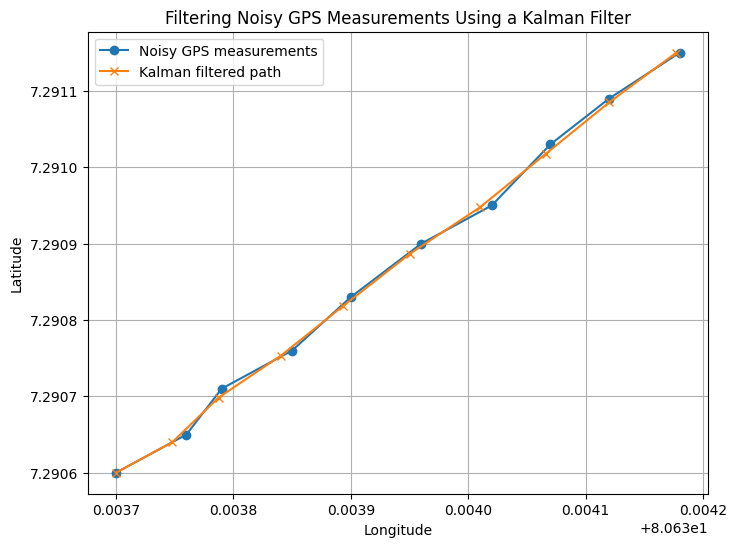

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------------------------
# Convert latitude and longitude to local x-y coordinates
# -------------------------------------------------
def latlon_to_xy(lat, lon, lat0, lon0):
    """
    Converts latitude and longitude to local Cartesian coordinates in meters.
    This approximation is suitable for small areas.
    """
    R_earth = 6371000  # Earth radius in meters

    lat = np.radians(lat)
    lon = np.radians(lon)
    lat0 = np.radians(lat0)
    lon0 = np.radians(lon0)

    x = R_earth * (lon - lon0) * np.cos(lat0)
    y = R_earth * (lat - lat0)

    return x, y


def xy_to_latlon(x, y, lat0, lon0):
    """
    Converts local x-y coordinates back to latitude and longitude.
    """
    R_earth = 6371000

    lat0_rad = np.radians(lat0)
    lon0_rad = np.radians(lon0)

    lat = y / R_earth + lat0_rad
    lon = x / (R_earth * np.cos(lat0_rad)) + lon0_rad

    return np.degrees(lat), np.degrees(lon)


# -------------------------------------------------
# Kalman filter for GPS measurements
# -------------------------------------------------
def kalman_filter_gps(gps_measurements, dt=1.0, gps_noise_std=5.0, acceleration_noise_std=1.0):
    """
    Filters noisy GPS latitude-longitude measurements using a 2-D Kalman filter.

    Parameters
    ----------
    gps_measurements : numpy array of shape (N, 2)
        GPS measurements in the form [latitude, longitude].
    dt : float
        Time step between measurements.
    gps_noise_std : float
        Standard deviation of GPS noise in meters.
    acceleration_noise_std : float
        Standard deviation of process acceleration noise.

    Returns
    -------
    filtered_latlon : numpy array of shape (N, 2)
        Filtered GPS positions as [latitude, longitude].
    filtered_states : numpy array of shape (N, 4)
        Estimated states [x, y, vx, vy].
    """

    gps_measurements = np.asarray(gps_measurements)

    lat_data = gps_measurements[:, 0]
    lon_data = gps_measurements[:, 1]

    # Use first GPS point as local reference
    lat0 = lat_data[0]
    lon0 = lon_data[0]

    # Convert GPS latitude-longitude to local x-y coordinates
    x_meas, y_meas = latlon_to_xy(lat_data, lon_data, lat0, lon0)
    measurements_xy = np.column_stack((x_meas, y_meas))

    n = len(measurements_xy)

    # State vector: [x, y, vx, vy]
    m = np.array([measurements_xy[0, 0], measurements_xy[0, 1], 0.0, 0.0])

    # Initial covariance
    P = np.eye(4) * 100.0

    # State transition matrix
    A = np.array([
        [1, 0, dt, 0],
        [0, 1, 0, dt],
        [0, 0, 1, 0],
        [0, 0, 0, 1]
    ])

    # Measurement matrix
    H = np.array([
        [1, 0, 0, 0],
        [0, 1, 0, 0]
    ])

    # Measurement noise covariance
    R = np.eye(2) * gps_noise_std**2

    # Process noise covariance based on acceleration uncertainty
    q = acceleration_noise_std**2

    Q = q * np.array([
        [dt**4 / 4, 0, dt**3 / 2, 0],
        [0, dt**4 / 4, 0, dt**3 / 2],
        [dt**3 / 2, 0, dt**2, 0],
        [0, dt**3 / 2, 0, dt**2]
    ])

    I = np.eye(4)

    filtered_states = []

    for k in range(n):

        # -----------------------------
        # Prediction step
        # -----------------------------
        m_prior = A @ m
        P_prior = A @ P @ A.T + Q

        # Current GPS measurement
        y_k = measurements_xy[k]

        # -----------------------------
        # Update step
        # -----------------------------
        innovation = y_k - H @ m_prior
        S = H @ P_prior @ H.T + R
        K = P_prior @ H.T @ np.linalg.inv(S)

        m = m_prior + K @ innovation
        P = (I - K @ H) @ P_prior

        filtered_states.append(m)

    filtered_states = np.array(filtered_states)

    # Convert filtered x-y positions back to latitude-longitude
    filtered_lat, filtered_lon = xy_to_latlon(
        filtered_states[:, 0],
        filtered_states[:, 1],
        lat0,
        lon0
    )

    filtered_latlon = np.column_stack((filtered_lat, filtered_lon))

    return filtered_latlon, filtered_states


# -------------------------------------------------
# Example GPS data
# Replace this with your own GPS measurements
# Format: [latitude, longitude]
# -------------------------------------------------
gps_measurements = np.array([
    [7.290600, 80.633700],
    [7.290650, 80.633760],
    [7.290710, 80.633790],
    [7.290760, 80.633850],
    [7.290830, 80.633900],
    [7.290900, 80.633960],
    [7.290950, 80.634020],
    [7.291030, 80.634070],
    [7.291090, 80.634120],
    [7.291150, 80.634180]
])

# Apply Kalman filter
filtered_latlon, filtered_states = kalman_filter_gps(
    gps_measurements,
    dt=1.0,
    gps_noise_std=5.0,
    acceleration_noise_std=1.0
)

print("Filtered GPS positions:")
print(filtered_latlon)


# -------------------------------------------------
# Plot noisy GPS path and filtered GPS path
# -------------------------------------------------
plt.figure(figsize=(8, 6))

plt.plot(
    gps_measurements[:, 1],
    gps_measurements[:, 0],
    marker="o",
    label="Noisy GPS measurements"
)

plt.plot(
    filtered_latlon[:, 1],
    filtered_latlon[:, 0],
    marker="x",
    label="Kalman filtered path"
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Filtering Noisy GPS Measurements Using a Kalman Filter")
plt.legend()
plt.grid(True)
plt.show()